## Installing Packages
Installing the API package to extract the retail datasets directly from the UCI Machine Learning Repository, as well as importing the necessary packages required to perform Data Exploration and Modelling.

In [1]:
#command is commented out when the installation is completed
#!pip install ucimlrepo

In [2]:
#importing the required packages
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, silhouette_score
from sklearn.cluster import KMeans

In [3]:
#loading the datasets based on the IDs, found in the URL of each one
session=fetch_ucirepo(id=468)
retail_history=fetch_ucirepo(id=352)

The returned object is a consolidation of the actual data, and the metadata of the datasets. Therefore, it is required that we save only the actual dataframe for the Exploratory Data Analysis. 
To extract only the dataframe, we must use the .data container that has multiple dataframes within it (i.e, only target variables, only input variables etc.). We use this container along with .original to obtain the entire dataframe exactly as the UCI ML repository hosts it.

In [4]:
session_data=session.data.original
retail_data=retail_history.data.original

In [5]:
#ensuring the number of rows and columns match with the dataset description and inspecting the first few rows in the datasets
print("The number of rows and columns for the Online Shoppers Purchasing Intention Dataset (The session data):",session_data.shape)
print(session_data.info())

The number of rows and columns for the Online Shoppers Purchasing Intention Dataset (The session data): (12330, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser       

In [6]:
print("The number of rows and columns for the Online Retail Dataset (The historical retail data):",retail_data.shape)
print(retail_data.info())

The number of rows and columns for the Online Retail Dataset (The historical retail data): (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


From the info method, it is observed that every variable in the Session data is a non-null value and requires no imputation or modification. However, the historical retail dataset has 135,080 null values in the Customer ID variable and 1,454 null values in the description column.

The description null values do not pose a problem in this particular analysis since the idea is to analyse customer behaviour and not NLP/Text processing, therefore they can simply have a place holder value.

The 135,080 null values in the Customer ID variable is a problem for this analysis since a transaction that has no Customer ID cannot be attributed to a single customer, hence there is valid way to include these transactions in model that is built around per customer behaviour. Imputation is not considered in this case, using a placeholder CustomerID for all these null values will create a single pseudo customer that has a very large monetary contribution for the company. 

In [7]:
#dropping the rows where the CustomerID is null
retail_data_complete=retail_data.dropna(subset="CustomerID").copy()
print(retail_data_complete.shape)
#inputing a pseudo description for the null values
retail_data_complete["Description"]=retail_data_complete["Description"].fillna("Unknown Description")
retail_data_complete.info()

(406829, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [8]:
#checking whether the Quantity has any impossible values, i.e, negative values
print((retail_data_complete["Quantity"]<0).sum())
retail_data_complete[retail_data_complete["Quantity"]<0].head()

8905


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


From the above inspection we see that there exists 8905 negative values in the quantity variable. On further investigation, it is noted that the first 5 orders that have negative quantities are cancelled orders, i.e, transactions where the invoice number begins with C, as described in the dataset description.

Now, it is checked whether every impossible value in quantity is associated with a cancelled order in the transactions.

In [9]:
negative_vals=retail_data_complete[retail_data_complete["Quantity"]<0]
cancelled_orders=negative_vals["InvoiceNo"].str.startswith("C")
cancelled_orders.value_counts()

InvoiceNo
True    8905
Name: count, dtype: int64

From the above inspection, it is observed that every negative value in the Quantity variable is associated with a cancelled order. Since every cancelled transaction was never kept or paid for, it does not represent retained value to the company. Therefore we drop all cancelled orders.

In [10]:
retail_data_complete=retail_data_complete[retail_data_complete["Quantity"]>0]
print(retail_data_complete.shape)

(397924, 8)


In [11]:
#checking if any prices are impossible values, i.e, negative values
print((retail_data_complete["UnitPrice"]<0).sum())

0


The session data has a target variable, Revenue, a binary variable stating whether a session resulted in a purchase or not. Hence, the dataset can be used to train supervised learning models, i.e classification models.
Before building the model, we need to understand the structure of the data, which means understanding whether the classes in the target variable are balanced or not.

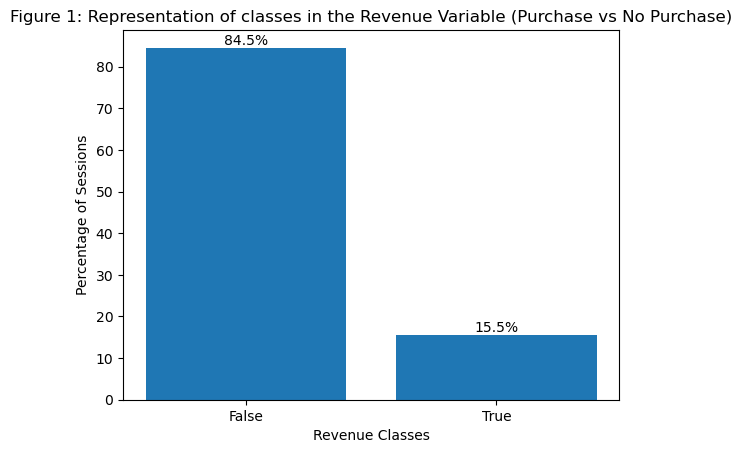

In [12]:
target_perc=session_data["Revenue"].value_counts(normalize=True)*100
fig,axes=plt.subplots()
bars=axes.bar(target_perc.index.astype(str),target_perc.values)
axes.bar_label(bars,labels=[f"{p:.1f}%" for p in target_perc])
axes.set_title("Figure 1: Representation of classes in the Revenue Variable (Purchase vs No Purchase)")
axes.set_xlabel("Revenue Classes")
axes.set_ylabel("Percentage of Sessions")
plt.show()

Figure 1 displays the class imbalance present in the Online Shoppers Purchasing Intention Dataset. From the bar graph it is evident that the sessions that resulted in no purchases dominate the dataset. This is integral to acknowledge, since a model can obtain a high accuracy just by predicting every session as a no purchase, with learning any patterns from the data. To account for this imbalance, Precision, Recall and Macro F1 score will be used to evaluate the model.
The Precision will identify how often predicted buyers purchase items, which will be relevant to the efficiency in marketing budget. Recall will identify how many real buyers were accurately identified, which is associated with avoiding potential revenue opportunities. The F1 score combines both, giving an equal weightage to both classes.

## Classification Model
### Support Vector Machines (SVMs)
To classify the session data into whether a session results in a purchase or not we use the Support Vector Machine Classifier algorithm. This algorithm finds the most optimal line that can accurately and confidently separate the sessions that resulted in a purchase and those that did not, and maximizes the distance between the two groups (reference)

In [13]:
#separating the input features and the target variable
input_features=session_data.drop(columns="Revenue")
target=session_data["Revenue"]

In [14]:
#splitting the dataset into training and test sets
input_train,input_test,target_train,target_test=train_test_split(input_features,target,test_size=0.30,stratify=target,random_state=28)

The data is split using the argument stratify, to compensate for the obvious class imbalance in dataset, where approximately 80% of the sessions resulted in no purchase. The test size is 30% of the data, leaving 70% for training.

Some columns like Month and VisitorType are stored as object (text) variables, which cannot be plotted on a coordinate axis. Therefore, it is required that they are converted from the human-readable format to a format that the machine can read. However, converting these columns into numeric values from 0-9 would imply that they have an inherent order, which is not the case. Therefore, sklearn's OneHotEncoder is used to convert the nominal columns into machine-readable formats.

It is also noted that some variables like Region, Operating Systems etc. are categorical variables that are encoded as numbers from 0-9, which is implying an order in the data. These columns are also encoded using the OneHotEncoder.

In [15]:
cat_columns=["Month","OperatingSystems","Browser","Region","TrafficType","VisitorType"]
#the encoder produces N-1 columns for every session, where N is the number of categories found in that variable
#the output will be a dense readable array
#if the encoder every sees a category that has never been identified before it just encodes it with all zeros
e=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
e.fit(input_train[cat_columns])
#transforming the training and test sets
train_transformed=e.transform(input_train[cat_columns])
test_transformed=e.transform(input_test[cat_columns])
new_cols=e.get_feature_names_out(cat_columns)
train_set=pd.DataFrame(train_transformed,columns=new_cols,index=input_train.index)
test_set=pd.DataFrame(test_transformed,columns=new_cols,index=input_test.index)

#creating the final training and test sets
input_train_encoded=input_train.drop(columns=cat_columns).join(train_set)
input_test_encoded=input_test.drop(columns=cat_columns).join(test_set)

print(input_train_encoded.shape)
print(input_test_encoded.shape)

(8631, 68)
(3699, 68)


Now, since all the categorical columns are encoded using the OneHotEncoder, the number of columns have drastically increased, this is because every category in the 6 categorical columns is converted into a column name. Now, since the SVM measures the distance between points to identify the optimal line separating the two classes, it is important that all numerical columns are on the same scale, to avoid the large differences between variables distorting the model.

In [16]:
num_cols=["Administrative","Administrative_Duration","Informational","Informational_Duration","ProductRelated","ProductRelated_Duration",
          "BounceRates","ExitRates","PageValues","SpecialDay"]
print(session_data[num_cols].skew())
#all the numeric columns produced a very large skew, therefore, before using the standard scaler the log transformation is applied
for c in num_cols:
    input_train_encoded[c]=np.log1p(input_train_encoded[c])
    input_test_encoded[c]=np.log1p(input_test_encoded[c])
scaler=StandardScaler()
input_train_encoded[num_cols]=scaler.fit_transform(input_train_encoded[num_cols])
input_test_encoded[num_cols]=scaler.transform(input_test_encoded[num_cols])


Administrative             1.960357
Administrative_Duration    5.615719
Informational              4.036464
Informational_Duration     7.579185
ProductRelated             4.341516
ProductRelated_Duration    7.263228
BounceRates                2.947855
ExitRates                  2.148789
PageValues                 6.382964
SpecialDay                 3.302667
dtype: float64


Before the kernel for the SVM is decided, a T-SNE plot is constructed to visualize the separation between both the classes. The plot will reduce the number of features to 2, so that a human can easily interpret them. If there exists a proper separation between the two classes, a linear kernel can be used to obtain the optimal line separating the two classes.

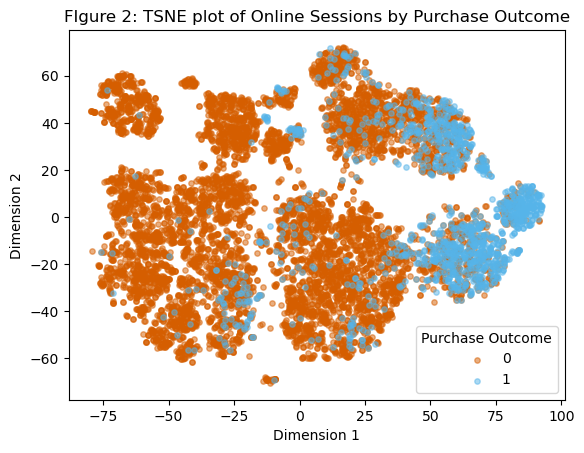

In [17]:
tsne=TSNE(n_components=2,random_state=28).fit_transform(input_train_encoded)
plt.figure()
for label,colour in zip([0,1],['#D55E00','#56B4E9']):
    mask=target_train.values.astype(int)==label
    plt.scatter(tsne[mask,0],tsne[mask,1],s=15,c=colour,label=label,alpha=0.5)
plt.title("FIgure 2: TSNE plot of Online Sessions by Purchase Outcome")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Purchase Outcome")
plt.show()

Figure 2 displays a small concentrated region of sessions that resulted in a purcharse which could possibly support the use of a linear kernel which would result in a straight line separating the two classes. However, there exists an ample number of purchase sessions that overlap with non-purchase sessions suggesting that there exists a real feature-space ambiguity. To identify which kernel is appropriate for this kind of data, both the linear and the rbf kernel will be evaluated using different score metrics.

In [18]:
#using a linear kernel first to find the optimal line separating the classes
svm=LinearSVC(class_weight="balanced",random_state=28) #reference this
svm.fit(input_train_encoded,target_train)

LinearSVC(class_weight='balanced', random_state=28)

In [19]:
#predicting the revenue variable
predicted=svm.predict(input_test_encoded)

In [20]:
# calculating all the metrics required to evaluate the model, along with the classification report
precision= precision_score(target_test, predicted)
recall=recall_score(target_test, predicted)
f1=f1_score(target_test, predicted)
print(f"Precision:{precision:.2f}")
print(f"Recall:{recall:.2f}")
print(f"F1 Score:{f1:.2f}")
print(classification_report(target_test,predicted))

Precision:0.58
Recall:0.77
F1 Score:0.66
              precision    recall  f1-score   support

       False       0.96      0.90      0.92      3127
        True       0.58      0.77      0.66       572

    accuracy                           0.88      3699
   macro avg       0.77      0.83      0.79      3699
weighted avg       0.90      0.88      0.88      3699



In [21]:
#performing the same process using the RBF kernel, plotting a curved line to separate the classes
svm_rbf_kernel= SVC(kernel="rbf",class_weight="balanced",random_state=28)
svm_rbf_kernel.fit(input_train_encoded,target_train)
predicted_rbf=svm_rbf_kernel.predict(input_test_encoded)
precision= precision_score(target_test, predicted_rbf)
recall=recall_score(target_test, predicted_rbf)
f1=f1_score(target_test, predicted_rbf)
print(f"Precision:{precision:.2f}")
print(f"Recall:{recall:.2f}")
print(f"F1 Score:{f1:.2f}")
print(classification_report(target_test,predicted_rbf))


Precision:0.54
Recall:0.84
F1 Score:0.66
              precision    recall  f1-score   support

       False       0.97      0.87      0.91      3127
        True       0.54      0.84      0.66       572

    accuracy                           0.86      3699
   macro avg       0.75      0.86      0.79      3699
weighted avg       0.90      0.86      0.88      3699



Choice

In [31]:
#obtaining the weights of the variables from the LinearSVC model
names=input_train_encoded.columns
weights=svm.coef_[0]
#creating a dataframe containing the variables and their correspnding coefficients
coeff_df=pd.DataFrame({
    "Variable (Feature)":names,
    "Coefficients":weights
}).sort_values("Coefficients",ascending=False)

coeff_df.head(10)

,Variable (Feature),Coefficients
25,OperatingSystems_7,0.626182
8,PageValues,0.555312
37,Browser_12,0.337707
26,OperatingSystems_8,0.321327
53,TrafficType_8,0.280081
17,Month_Nov,0.247949
56,TrafficType_11,0.225530
50,TrafficType_5,0.184967
65,TrafficType_20,0.184828
52,TrafficType_7,0.178558


## Clustering Model

### K-Means Clustering

In this part of the project, RFM Analysis will be performed. RFM Analysis summarizes the customer's behaviour by analysing the time past since their last purchase (Recency), the number of purchases made (Frequency) and the monetary value they bring to the company (Monetary). To perform this analysis, an unsupervised learning algorithm is used, called K-Means Clustering.

K-Means Clustering works by randomly assigning k centroids in the feature space. Then, each customer/point is assigned to it's closest centroid based on Euclidean distance. The position of the centroid is then updated as the average of all the points associated with it and the points are reassigned to the nearest centroid. The process is repeated until the positions of the updated centroid do not move more than a very tiny distance; this means that the centroid has been stabilised and no further reallocation occurs.
However, for this to work, the input must be one row per customer, but right now the dataset contains one row per transaction.

In [23]:
#creating the reference point for the Recency Data, this day will be the last date in the dataset+1
#converting the Date into a datetime object
retail_data_complete["InvoiceDate"]=pd.to_datetime(retail_data_complete["InvoiceDate"])
reference=retail_data_complete["InvoiceDate"].max()+pd.Timedelta(days=1)
print(reference)

2011-12-10 12:50:00


In [24]:
#creating the total price for every transaction
retail_data_complete["TotalPrice"]=retail_data_complete["UnitPrice"]*retail_data_complete["Quantity"]

In [25]:
#creating the RFM dataframe for every customer
recency=retail_data_complete.groupby("CustomerID")["InvoiceDate"].max()
recency=(reference-recency).dt.days
frequency=retail_data_complete.groupby("CustomerID")["InvoiceNo"].nunique()
monetary=retail_data_complete.groupby("CustomerID")["TotalPrice"].sum()
rfm_data=pd.DataFrame({"Recency":recency,"Frequency":frequency,"Monetary Value":monetary}).reset_index()
rfm_data.shape
rfm_data.skew()

CustomerID         0.001433
Recency            1.246357
Frequency         12.100028
Monetary Value    19.326985
dtype: float64

It is observed that all three variables exhibit skewness, with Frequency and Monetary values being extremely skewed. If the values were retained as-is, then the clusters would be distorted by extreme values. However, this cannot be scaled simply by the StandardScaler since it scales based on average which is affected by outliers. All three variables will undergo log transformation before scaling.

In [26]:
rfm_data["Recency_log"]=np.log1p(rfm_data["Recency"])
rfm_data["Frequency_log"]=np.log1p(rfm_data["Frequency"])
rfm_data["Monetary_log"]=np.log1p(rfm_data["Monetary Value"])
#scaling the log values
scaler_cluster=StandardScaler()
rfm_scaled=scaler_cluster.fit_transform(rfm_data[["Recency_log","Frequency_log","Monetary_log"]])

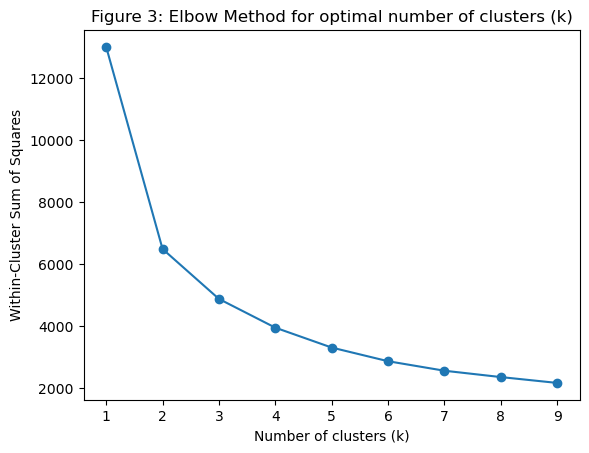

In [27]:
#plotting the WCSS (Inertia) vs Number of clusters to use the elbow method and decide the number of clusters
WCSS=[]
k_cluster_range=range(1,10)

for k in k_cluster_range:
    clustering=KMeans(n_clusters=k,random_state=28,n_init=10)
    clustering.fit(rfm_scaled)
    WCSS.append(clustering.inertia_)

plt.figure()
plt.plot(k_cluster_range,WCSS,marker="o")
plt.title("Figure 3: Elbow Method for optimal number of clusters (k)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.show()

In [28]:
#computing the silhouette scores for some k values to confirm the optimality of cluster number
for k in [2,3,4]:
    clustering_ss=KMeans(n_clusters=k,random_state=28,n_init=10)
    cluster_labels=clustering_ss.fit_predict(rfm_scaled)
    ss=silhouette_score(rfm_scaled,cluster_labels)
    print(f"For k={k}, Silhouette Score = {ss:.4f}")

For k=2, Silhouette Score = 0.4327
For k=3, Silhouette Score = 0.3364
For k=4, Silhouette Score = 0.3372


Choice

In [29]:
#using the optimal value of k=4 to compute the final clusters
kmeans_optimal=KMeans(n_clusters=4,random_state=28,n_init=10)
rfm_data["Cluster"]=kmeans_optimal.fit_predict(rfm_scaled)

print(rfm_data.groupby("Cluster")[["Recency","Frequency","Monetary Value"]].mean())

            Recency  Frequency  Monetary Value
Cluster                                       
0         17.665865   2.187500      561.923257
1        181.220308   1.316923      341.823748
2         71.552226   4.078767     1806.307006
3         12.161064  13.742297     8093.357955


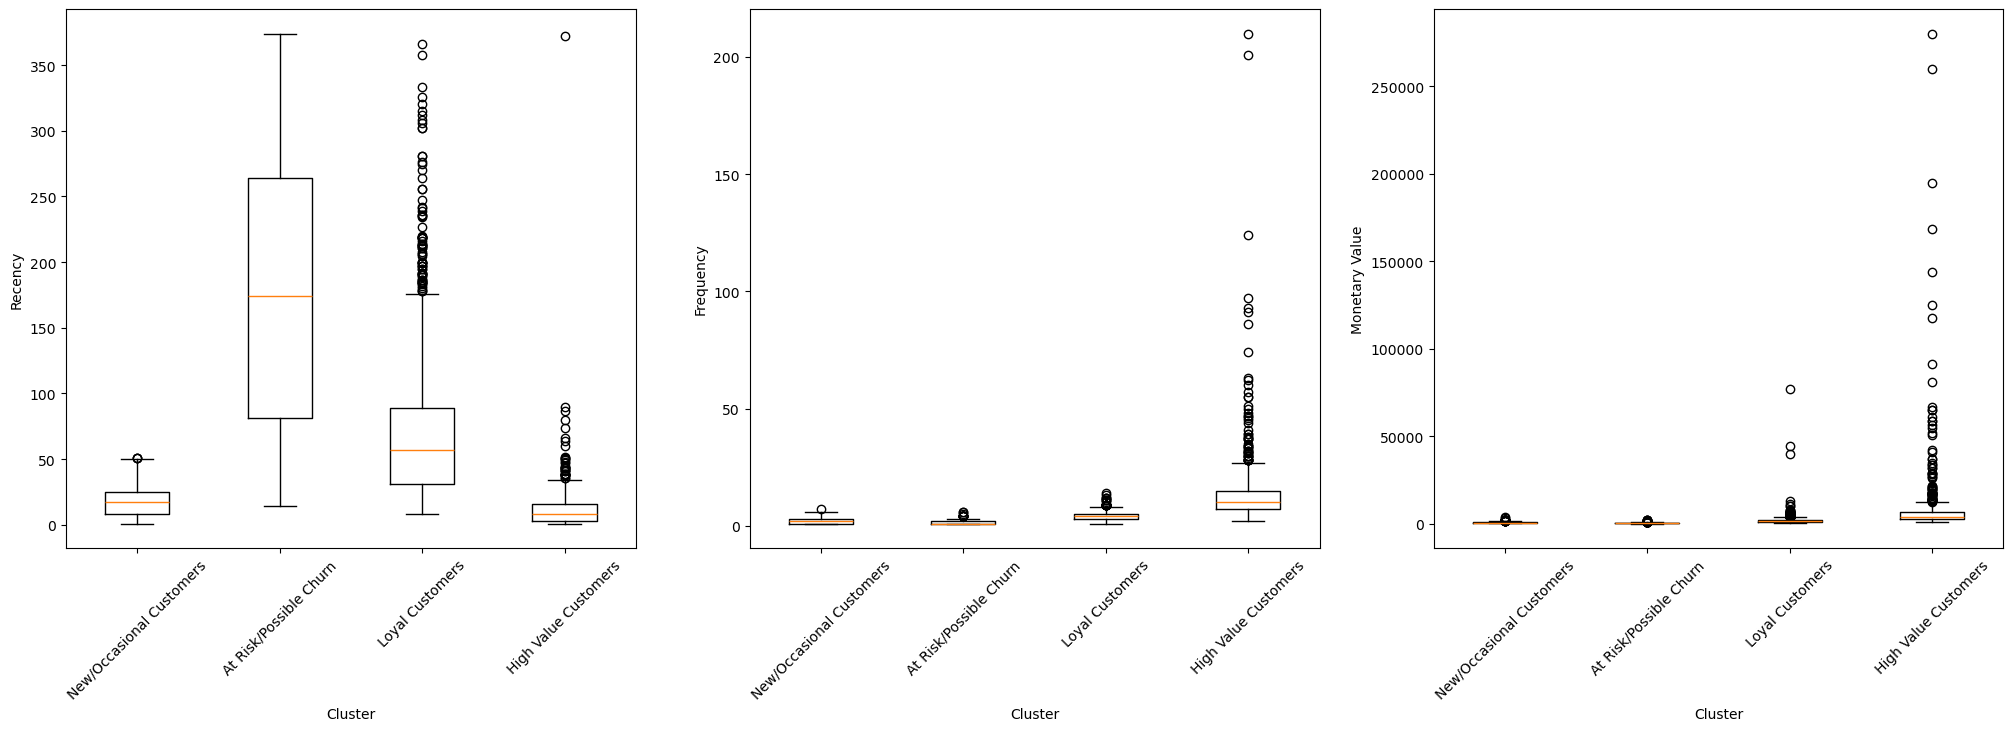

In [30]:
#plotting a boxplot for every cluster against every metric in the RFM analysis
fig,axes=plt.subplots(1,3,figsize=(25,7))
variables=["Recency","Frequency","Monetary Value"]
cluster_values=sorted(rfm_data["Cluster"].unique())
cluster_names={0:"New/Occasional Customers",1:"At Risk/Possible Churn",2:"Loyal Customers",3:"High Value Customers"}
axes_labels=[cluster_names[c] for c in cluster_values]
for a,v in zip(axes,variables):
    cluster_data=[rfm_data[rfm_data["Cluster"]==c][v] for c in cluster_values]
    a.boxplot(cluster_data, tick_labels=axes_labels)
    a.set_xlabel("Cluster")
    a.set_ylabel(v)
    a.tick_params(axis="x",rotation=45)

plt.show()